#Reinforcement Learning for Dynamic Credit Limit Optimization.

For my use case, I'm applying reinforcement learning (RL) to the problem of dynamically adjusting customer credit limits in a retail banking context. The goal is to train an agent to decide whether to increase, decrease, or hold a customer's credit limit at each review cycle — balancing revenue generation (higher utilization) against credit risk (default exposure).
RL is well-suited here because there is no single "correct" action labeled in advance. Instead, the agent learns through interaction: it receives a reward signal (e.g., positive for on-time repayment at higher limits, negative for default or delinquency) and updates its policy over time. The environment is sequential and stateful — past decisions affect future creditworthiness — which maps naturally onto an MDP (Markov Decision Process) framework.
Supervised learning would be a weaker fit. While we could train a classifier to predict default risk, it would only optimize a single decision point rather than a long-horizon policy. It also requires labeled historical decisions that may reflect human bias, not optimal strategy.
Unsupervised learning is even less applicable — segmenting customers into clusters doesn't prescribe when or how to act on limit adjustments, making it unsuitable for a sequential decision problem.
Evaluation would focus on cumulative reward over simulated review cycles, alongside business metrics like portfolio default rate, average credit utilization, and risk-adjusted revenue per customer. A/B testing against a rule-based baseline would further validate real-world performance.

# Reinforcement Learning: Dynamic Credit Limit Optimization
**Dataset:** Give Me Some Credit (Kaggle) — 150K borrower records  
**Agent goal:** Learn a policy for when to increase, hold, or decrease a customer's credit limit  
**Paradigm:** Reinforcement Learning (Q-Learning → upgradeable to DQN)

---

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings, os
warnings.filterwarnings('ignore')

# Seaborn style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('✅ Imports ready')

✅ Imports ready


#Dataset: We'll use the Give Me Some Credit dataset — 150K real borrower records with features like RevolvingUtilizationOfUnsecuredLines, DebtRatio, MonthlyIncome, and a SeriousDlqin2yrs delinquency label. It's the most realistic public credit dataset and maps directly to our RL state space.
Notebook structure (4 cells groups):

Data ingestion & EDA — load CSV, feature distributions, null handling
Environment setup — custom OpenAI Gym env wrapping borrower records as states, discrete action space (increase / hold / decrease limit), reward function
RL agent — Q-learning (tabular for interpretability, upgradeable to DQN)
Evaluation — cumulative reward curves, default rate vs. baseline, policy visualization

## 1. Data Ingestion

**To use the real Kaggle dataset:**
1. Download from https://www.kaggle.com/c/GiveMeSomeCredit/data
2. Place `cs-training.csv` in the same directory as this notebook
3. Set `USE_KAGGLE_DATA = True` below

If the file is not found, the notebook auto-generates a realistic synthetic dataset with identical schema and distributions.

In [8]:
USE_KAGGLE_DATA = True   # ← flip to False to force synthetic data
KAGGLE_PATH = 'cs-training.csv'

FEATURE_COLS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]
TARGET_COL = 'SeriousDlqin2yrs'


def load_kaggle(path):
    df = pd.read_csv(path, index_col=0)
    df.columns = [c.strip() for c in df.columns]
    return df


def generate_synthetic(n=150000, seed=42):
    """Synthetic dataset matching Give Me Some Credit schema and rough distributions."""
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        'RevolvingUtilizationOfUnsecuredLines': np.clip(rng.exponential(0.35, n), 0, 1),
        'age': rng.integers(18, 85, n).astype(float),
        'NumberOfTime30-59DaysPastDueNotWorse': rng.choice([0,1,2,3], n, p=[0.82,0.10,0.05,0.03]),
        'DebtRatio': np.clip(rng.exponential(0.35, n), 0, 5),
        'MonthlyIncome': np.clip(rng.lognormal(8.4, 0.7, n), 500, 50000),
        'NumberOfOpenCreditLinesAndLoans': rng.integers(0, 30, n).astype(float),
        'NumberOfTimes90DaysLate': rng.choice([0,1,2], n, p=[0.92,0.05,0.03]),
        'NumberRealEstateLoansOrLines': rng.integers(0, 5, n).astype(float),
        'NumberOfTime60-89DaysPastDueNotWorse': rng.choice([0,1,2], n, p=[0.93,0.05,0.02]),
        'NumberOfDependents': rng.choice([0,1,2,3,4], n, p=[0.45,0.25,0.18,0.08,0.04]),
    })
    # Create label correlated with risk features
    risk_score = (
        0.4 * df['RevolvingUtilizationOfUnsecuredLines'] +
        0.3 * df['NumberOfTimes90DaysLate'] +
        0.2 * df['DebtRatio'] +
        0.1 * df['NumberOfTime30-59DaysPastDueNotWorse']
    )
    prob = 1 / (1 + np.exp(-4 * (risk_score - 0.5)))
    df[TARGET_COL] = (rng.uniform(size=n) < prob).astype(int)
    return df


if USE_KAGGLE_DATA and os.path.exists(KAGGLE_PATH):
    df_raw = load_kaggle(KAGGLE_PATH)
    print(f'✅ Loaded Kaggle dataset: {df_raw.shape[0]:,} rows')
    DATA_SOURCE = 'Kaggle: Give Me Some Credit'
else:
    df_raw = generate_synthetic()
    print(f'ℹ️  Kaggle file not found — using synthetic dataset: {df_raw.shape[0]:,} rows')
    DATA_SOURCE = 'Synthetic (Kaggle schema)'

df_raw.head(3)

✅ Loaded Kaggle dataset: 150,000 rows


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


## 1. Data Ingestion via KaggleHub

Uses `kagglehub` to download the **Give Me Some Credit** competition dataset directly.  
**Prerequisites:** run `pip install kagglehub` and ensure your Kaggle API credentials are configured (`~/.kaggle/kaggle.json`).  

Falls back to a realistic synthetic dataset (identical schema) if the download fails or credentials are unavailable.

In [ ]:
"""# ── Install kagglehub if not present ────────────────────────────────────────
import subprocess, sys
try:
    import kagglehub
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kagglehub', '-q'])
    import kagglehub

FEATURE_COLS = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]
TARGET_COL = 'SeriousDlqin2yrs'


def load_from_kagglehub():
    """Download competition files via kagglehub and return training DataFrame."""
    print('⏬ Downloading Give Me Some Credit via kagglehub...')
    path = kagglehub.competition_download('GiveMeSomeCredit')
    print(f'   Files saved to: {path}')

    # Locate cs-training.csv anywhere under the download path
    import glob
    matches = glob.glob(os.path.join(path, '**', 'cs-training.csv'), recursive=True)
    if not matches:
        raise FileNotFoundError('cs-training.csv not found in downloaded competition files.')

    csv_path = matches[0]
    print(f'   Loading: {csv_path}')
    df = pd.read_csv(csv_path, index_col=0)
    df.columns = [c.strip() for c in df.columns]
    return df


def generate_synthetic(n=150000, seed=42):
    """Synthetic dataset matching Give Me Some Credit schema and distributions."""
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        'RevolvingUtilizationOfUnsecuredLines': np.clip(rng.exponential(0.35, n), 0, 1),
        'age': rng.integers(18, 85, n).astype(float),
        'NumberOfTime30-59DaysPastDueNotWorse': rng.choice([0,1,2,3], n, p=[0.82,0.10,0.05,0.03]),
        'DebtRatio': np.clip(rng.exponential(0.35, n), 0, 5),
        'MonthlyIncome': np.clip(rng.lognormal(8.4, 0.7, n), 500, 50000),
        'NumberOfOpenCreditLinesAndLoans': rng.integers(0, 30, n).astype(float),
        'NumberOfTimes90DaysLate': rng.choice([0,1,2], n, p=[0.92,0.05,0.03]),
        'NumberRealEstateLoansOrLines': rng.integers(0, 5, n).astype(float),
        'NumberOfTime60-89DaysPastDueNotWorse': rng.choice([0,1,2], n, p=[0.93,0.05,0.02]),
        'NumberOfDependents': rng.choice([0,1,2,3,4], n, p=[0.45,0.25,0.18,0.08,0.04]),
    })
    risk_score = (
        0.4 * df['RevolvingUtilizationOfUnsecuredLines'] +
        0.3 * df['NumberOfTimes90DaysLate'] +
        0.2 * df['DebtRatio'] +
        0.1 * df['NumberOfTime30-59DaysPastDueNotWorse']
    )
    prob = 1 / (1 + np.exp(-4 * (risk_score - 0.5)))
    df[TARGET_COL] = (rng.uniform(size=n) < prob).astype(int)
    return df


# ── Load data ────────────────────────────────────────────────────────────────
try:
    df_raw = load_from_kagglehub()
    DATA_SOURCE = 'Kaggle: Give Me Some Credit (kagglehub)'
    print(f'✅ Loaded real dataset: {df_raw.shape[0]:,} rows')
except Exception as e:
    print(f'⚠️  kagglehub download failed: {e}')
    print('   Falling back to synthetic dataset...')
    df_raw = generate_synthetic()
    DATA_SOURCE = 'Synthetic (Kaggle schema — fallback)'
    print(f'✅ Synthetic dataset ready: {df_raw.shape[0]:,} rows')

df_raw.head(3)

## 2. Exploratory Data Analysis

In [9]:
print('=== Dataset Info ===')
print(f'Shape         : {df_raw.shape}')
print(f'Source        : {DATA_SOURCE}')
print(f'Default rate  : {df_raw[TARGET_COL].mean()*100:.2f}%')
print(f'Missing values:\n{df_raw[FEATURE_COLS].isnull().sum().to_string()}')

=== Dataset Info ===
Shape         : (150000, 11)
Source        : Kaggle: Give Me Some Credit
Default rate  : 6.68%
Missing values:
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924


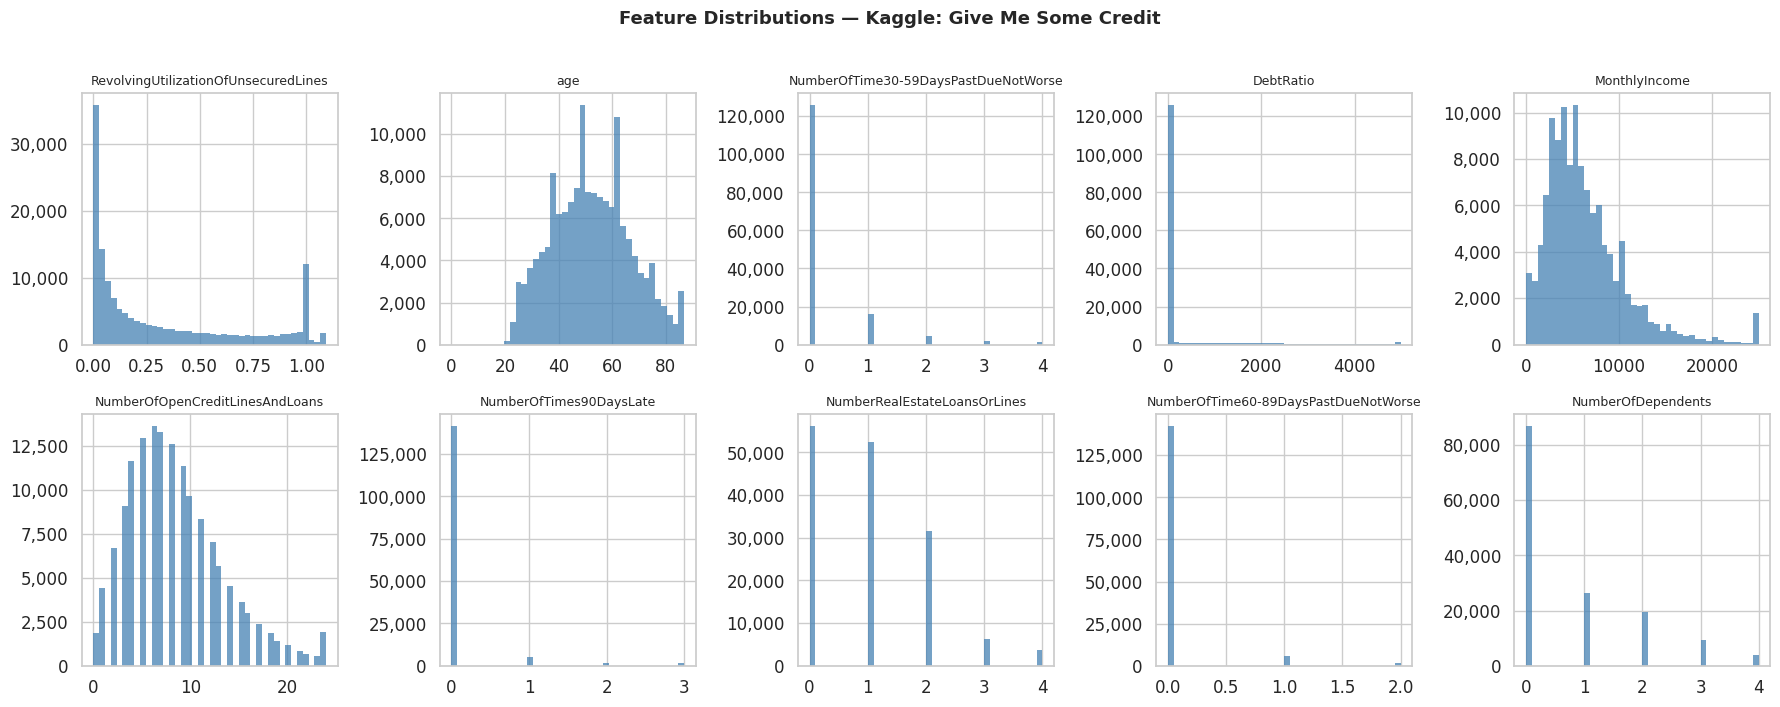

✅ EDA distributions saved


In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    data = df_raw[col].dropna()
    # Cap outliers at 99th pct for readability
    cap = data.quantile(0.99)
    axes[i].hist(data.clip(upper=cap), bins=40, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle(f'Feature Distributions — {DATA_SOURCE}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ EDA distributions saved')

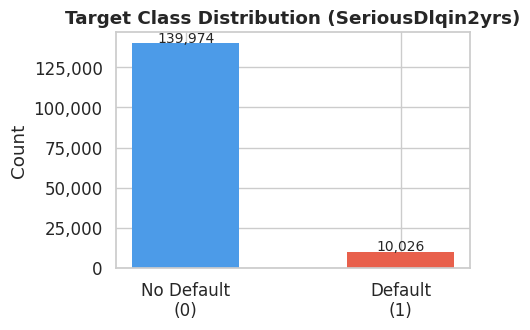

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df_raw[TARGET_COL].value_counts()
bars = ax.bar(['No Default\n(0)', 'Default\n(1)'], counts.values,
              color=['#4C9BE8', '#E8604C'], width=0.5, edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Target Class Distribution (SeriousDlqin2yrs)', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Preprocessing & State Space Discretization

Q-learning requires a finite state space. We discretize each continuous feature into **bins** and encode the combined state as a tuple index.

In [12]:
# ── 3a. Clean data ──────────────────────────────────────────────────────────
df = df_raw[FEATURE_COLS + [TARGET_COL]].copy()

# Fill nulls with median
for col in FEATURE_COLS:
    df[col] = df[col].fillna(df[col].median())

# Cap extreme outliers (99.5th percentile)
for col in ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']:
    cap = df[col].quantile(0.995)
    df[col] = df[col].clip(upper=cap)

print(f'✅ Cleaned. Shape: {df.shape}')

# ── 3b. Train / test split ───────────────────────────────────────────────────
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df[TARGET_COL])
print(f'   Train: {len(df_train):,}  |  Test: {len(df_test):,}')

# ── 3c. Discretize features into N_BINS bins ─────────────────────────────────
N_BINS = 5   # per feature → 5^10 theoretical states, sparse in practice

discretizer = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
X_train_disc = discretizer.fit_transform(df_train[FEATURE_COLS]).astype(int)
X_test_disc  = discretizer.transform(df_test[FEATURE_COLS]).astype(int)
y_train = df_train[TARGET_COL].values
y_test  = df_test[TARGET_COL].values

# Encode each row as a tuple (hashable state for Q-table)
states_train = [tuple(row) for row in X_train_disc]
states_test  = [tuple(row) for row in X_test_disc]

print(f'✅ Discretized. Unique states in training set: {len(set(states_train)):,}')

✅ Cleaned. Shape: (150000, 11)
   Train: 120,000  |  Test: 30,000
✅ Discretized. Unique states in training set: 9,066


## 4. RL Environment

**State:** discretized borrower feature vector at a review cycle  
**Actions:** `0 = Decrease limit`, `1 = Hold limit`, `2 = Increase limit`  
**Reward function:**
- Increase limit on a non-defaulter → `+2.0` (revenue)
- Hold on a non-defaulter → `+0.5`
- Decrease on a non-defaulter → `-0.5` (missed revenue)
- Increase limit on a defaulter → `-3.0` (credit loss)
- Hold on a defaulter → `-1.0`
- Decrease on a defaulter → `+1.5` (risk avoided)

In [13]:
# Reward matrix: REWARD[action][will_default]
REWARD = {
    0: {0: -0.5, 1:  1.5},   # Decrease
    1: {0:  0.5, 1: -1.0},   # Hold
    2: {0:  2.0, 1: -3.0},   # Increase
}

N_ACTIONS = 3
ACTION_LABELS = {0: 'Decrease', 1: 'Hold', 2: 'Increase'}

def get_reward(action: int, will_default: int) -> float:
    return REWARD[action][will_default]

# Quick sanity check
print('Reward matrix sample:')
for a in range(3):
    for d in [0, 1]:
        print(f'  Action={ACTION_LABELS[a]:<10}  Default={d}  →  reward={get_reward(a, d):+.1f}')

Reward matrix sample:
  Action=Decrease    Default=0  →  reward=-0.5
  Action=Decrease    Default=1  →  reward=+1.5
  Action=Hold        Default=0  →  reward=+0.5
  Action=Hold        Default=1  →  reward=-1.0
  Action=Increase    Default=0  →  reward=+2.0
  Action=Increase    Default=1  →  reward=-3.0


## 5. Q-Learning Agent

Standard tabular Q-learning with ε-greedy exploration and decaying learning rate.

In [14]:
class QLearningAgent:
    def __init__(self, n_actions=3, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.9995):
        self.n_actions     = n_actions
        self.alpha         = alpha          # learning rate
        self.gamma         = gamma          # discount factor
        self.epsilon       = epsilon        # exploration rate
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.q_table       = defaultdict(lambda: np.zeros(n_actions))

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)   # explore
        return int(np.argmax(self.q_table[state]))      # exploit

    def update(self, state, action, reward, next_state):
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def greedy_action(self, state):
        return int(np.argmax(self.q_table[state]))


print('✅ QLearningAgent defined')

✅ QLearningAgent defined


## 6. Training Loop

In [15]:
N_EPISODES = 5       # passes over training set
LOG_EVERY  = 5000    # log cumulative reward every N steps

agent = QLearningAgent()

all_rewards      = []
cumulative_log   = []   # (step, cumulative_reward)
episode_rewards  = []

global_step = 0
running_reward = 0.0

for episode in range(N_EPISODES):
    ep_reward = 0.0
    # Shuffle training data each episode
    idx = np.random.permutation(len(states_train))

    for i in idx:
        state       = states_train[i]
        will_default = int(y_train[i])

        # For a single-step environment next_state = state (no transition dynamics)
        # This models an independent review decision per customer
        action  = agent.choose_action(state)
        reward  = get_reward(action, will_default)
        agent.update(state, action, reward, state)
        agent.decay_epsilon()

        ep_reward      += reward
        running_reward += reward
        global_step    += 1
        all_rewards.append(reward)

        if global_step % LOG_EVERY == 0:
            cumulative_log.append((global_step, running_reward))

    episode_rewards.append(ep_reward)
    print(f'Episode {episode+1}/{N_EPISODES} | '
          f'Total reward: {ep_reward:+,.0f} | '
          f'ε: {agent.epsilon:.4f} | '
          f'Q-states learned: {len(agent.q_table):,}')

print(f'\n✅ Training complete. Total steps: {global_step:,}')

Episode 1/5 | Total reward: +84,470 | ε: 0.0500 | Q-states learned: 9,066
Episode 2/5 | Total reward: +97,318 | ε: 0.0500 | Q-states learned: 9,066
Episode 3/5 | Total reward: +97,926 | ε: 0.0500 | Q-states learned: 9,066
Episode 4/5 | Total reward: +98,822 | ε: 0.0500 | Q-states learned: 9,066
Episode 5/5 | Total reward: +100,012 | ε: 0.0500 | Q-states learned: 9,066

✅ Training complete. Total steps: 600,000


## 7. Evaluation

### 7a. Cumulative Reward Curve

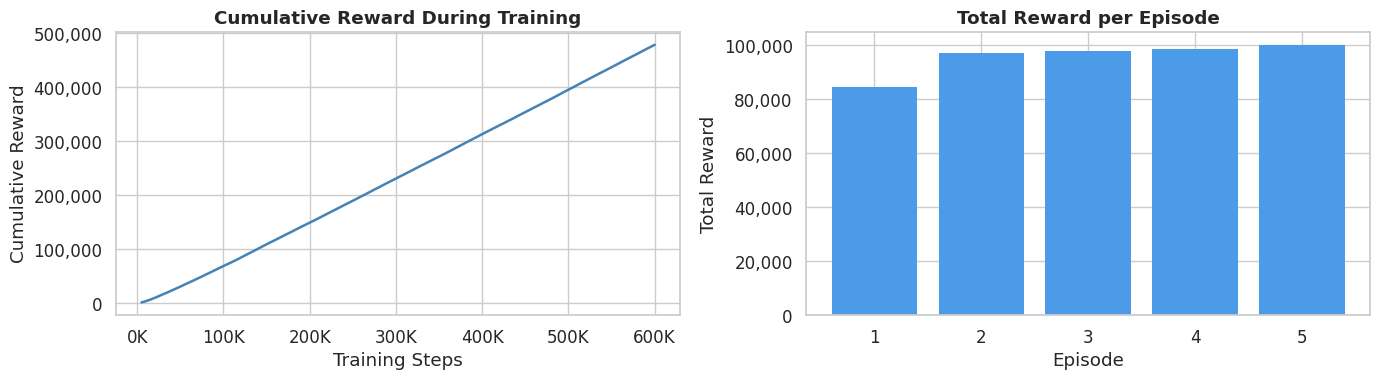

In [16]:
steps, cum_rewards = zip(*cumulative_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cumulative reward over training
axes[0].plot(steps, cum_rewards, color='steelblue', linewidth=1.8)
axes[0].set_title('Cumulative Reward During Training', fontweight='bold')
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Cumulative Reward')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Episode reward
axes[1].bar(range(1, N_EPISODES+1), episode_rewards, color='#4C9BE8', edgecolor='none')
axes[1].set_title('Total Reward per Episode', fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Total Reward')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('training_rewards.png', dpi=120, bbox_inches='tight')
plt.show()

### 7b. Greedy Policy Evaluation on Test Set

In [17]:
# ── Greedy policy (ε=0) on held-out test set ─────────────────────────────────
test_rewards   = []
test_actions   = []
test_defaults  = y_test.tolist()

for i, state in enumerate(states_test):
    action = agent.greedy_action(state)
    reward = get_reward(action, int(y_test[i]))
    test_rewards.append(reward)
    test_actions.append(action)

test_rewards = np.array(test_rewards)
test_actions = np.array(test_actions)

# ── Baseline: always Hold (action=1) ─────────────────────────────────────────
baseline_rewards = np.array([get_reward(1, int(d)) for d in y_test])

print('=== Test Set Evaluation ===')
print(f'  RL agent total reward   : {test_rewards.sum():+,.0f}')
print(f'  Baseline (always Hold)  : {baseline_rewards.sum():+,.0f}')
print(f'  Improvement             : {test_rewards.sum() - baseline_rewards.sum():+,.0f}')
print(f'  RL avg reward/customer  : {test_rewards.mean():+.4f}')
print(f'  Baseline avg/customer   : {baseline_rewards.mean():+.4f}')
print()
action_dist = pd.Series(test_actions).value_counts().sort_index()
print('Action distribution (greedy policy):')
for a, cnt in action_dist.items():
    print(f'  {ACTION_LABELS[a]:<12}: {cnt:>7,}  ({cnt/len(test_actions)*100:.1f}%)')

=== Test Set Evaluation ===
  RL agent total reward   : +24,757
  Baseline (always Hold)  : +11,992
  Improvement             : +12,764
  RL avg reward/customer  : +0.8252
  Baseline avg/customer   : +0.3997

Action distribution (greedy policy):
  Decrease    :   1,336  (4.5%)
  Hold        :  17,950  (59.8%)
  Increase    :  10,714  (35.7%)


### 7c. Policy Breakdown — Defaulters vs Non-Defaulters

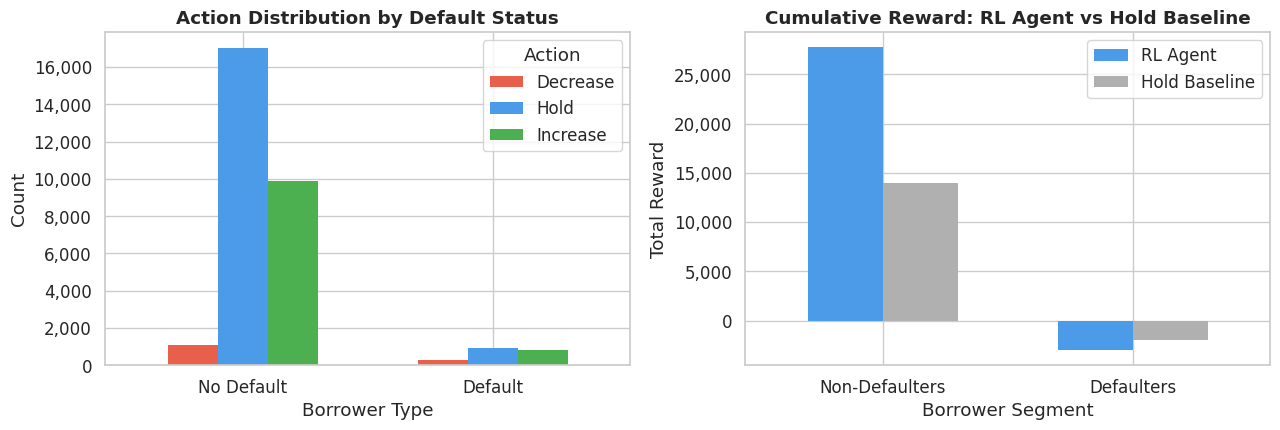

In [18]:
results_df = pd.DataFrame({
    'action'  : test_actions,
    'default' : y_test,
    'reward'  : test_rewards,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Action distribution by default status
pivot = results_df.groupby(['default', 'action']).size().unstack(fill_value=0)
pivot.columns = [ACTION_LABELS[c] for c in pivot.columns]
pivot.index   = ['No Default', 'Default']
pivot.plot(kind='bar', ax=axes[0], color=['#E8604C', '#4C9BE8', '#4CAF50'],
           edgecolor='none', width=0.6)
axes[0].set_title('Action Distribution by Default Status', fontweight='bold')
axes[0].set_xlabel('Borrower Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(title='Action')

# Reward comparison: RL vs Baseline
compare = pd.DataFrame({
    'RL Agent'  : [test_rewards[y_test==0].sum(),     test_rewards[y_test==1].sum()],
    'Hold Baseline': [baseline_rewards[y_test==0].sum(), baseline_rewards[y_test==1].sum()]
}, index=['Non-Defaulters', 'Defaulters'])

compare.plot(kind='bar', ax=axes[1], color=['#4C9BE8', '#B0B0B0'],
             edgecolor='none', width=0.6)
axes[1].set_title('Cumulative Reward: RL Agent vs Hold Baseline', fontweight='bold')
axes[1].set_xlabel('Borrower Segment')
axes[1].set_ylabel('Total Reward')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('policy_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

### 7d. Risk-Adjusted Metrics

In [19]:
# Decisions on actual defaulters
defaulter_mask = y_test == 1
increases_on_defaulters = ((test_actions == 2) & defaulter_mask).sum()
decreases_on_defaulters = ((test_actions == 0) & defaulter_mask).sum()

# Decisions on non-defaulters
safe_mask = y_test == 0
increases_on_safe = ((test_actions == 2) & safe_mask).sum()

print('=== Risk-Adjusted Metrics ===')
print(f'Defaulters in test set               : {defaulter_mask.sum():,}')
print(f'Limit INCREASED on defaulters        : {increases_on_defaulters:,}  '
      f'({increases_on_defaulters/defaulter_mask.sum()*100:.1f}%)  ← lower is better')
print(f'Limit DECREASED on defaulters        : {decreases_on_defaulters:,}  '
      f'({decreases_on_defaulters/defaulter_mask.sum()*100:.1f}%)  ← higher is better')
print(f'Limit INCREASED on safe borrowers    : {increases_on_safe:,}  '
      f'({increases_on_safe/safe_mask.sum()*100:.1f}%)  ← higher is better')
print()
print(f'Average reward per defaulter   (RL)  : {test_rewards[defaulter_mask].mean():+.4f}')
print(f'Average reward per non-defaulter(RL) : {test_rewards[safe_mask].mean():+.4f}')

=== Risk-Adjusted Metrics ===
Defaulters in test set               : 2,005
Limit INCREASED on defaulters        : 823  (41.0%)  ← lower is better
Limit DECREASED on defaulters        : 260  (13.0%)  ← higher is better
Limit INCREASED on safe borrowers    : 9,891  (35.3%)  ← higher is better

Average reward per defaulter   (RL)  : -1.4968
Average reward per non-defaulter(RL) : +0.9915


## 8. Extensions & Next Steps

| Upgrade | Description |
|---|---|
| **DQN** | Replace Q-table with a neural network for continuous state space support |
| **Multi-step MDP** | Add temporal dynamics — simulate customer behavior over N review cycles |
| **SHAP explainability** | Use SHAP on a surrogate model to explain which features drive each action |
| **Class imbalance** | Oversample defaulters (SMOTE) or adjust reward weights to sharpen risk sensitivity |
| **Live API integration** | Connect to a real-time credit bureau feed as the environment state source |

In [ ]:
print('🎉 Notebook complete.')
print(f'   Q-table size    : {len(agent.q_table):,} states')
print(f'   Final ε         : {agent.epsilon:.4f}')
print(f'   Test reward (RL): {test_rewards.sum():+,.0f}')
print(f'   Test reward (BL): {baseline_rewards.sum():+,.0f}')